In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config/config.yaml").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.runtime import configure_runtime
configure_runtime(headless=False)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config/config.yaml").exists())
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "SOLETE_short.h5"

print(DATA_PATH)
print(DATA_PATH.exists())

c:\Users\felix\Github\pv\data\raw\SOLETE_short.h5
True


In [4]:
df = pd.read_hdf(DATA_PATH)
df.head()

,TEMPERATURE[degC],HUMIDITY[%],WIND_SPEED[m1s],WIND_DIR[deg],GHI[kW1m2],POA Irr[kW1m2],P_Gaia[kW],P_Solar[kW],Pressure[mbar]
2018-06-01 00:00:00,14.165157,0.700000,1.306307,109.657127,0.000000,0.000000,0.037694,0.000000,1017.473418
2018-06-01 01:00:00,13.392278,0.700000,1.018417,117.161389,0.000000,0.000000,0.009697,0.000000,1017.223940
2018-06-01 02:00:00,13.047472,0.701278,1.094333,102.706111,0.002930,0.003503,0.000000,0.026999,1017.017803
2018-06-01 03:00:00,13.105583,0.731361,0.750222,68.054722,0.035402,0.021412,0.000000,0.164586,1016.676217
2018-06-01 04:00:00,14.680333,0.700000,1.069194,79.820556,0.117444,0.050737,0.000392,0.276209,1016.733249


In [5]:
missing = df.isna().sum()

missing

TEMPERATURE[degC]    0
HUMIDITY[%]          0
WIND_SPEED[m1s]      0
WIND_DIR[deg]        0
GHI[kW1m2]           0
POA Irr[kW1m2]       0
P_Gaia[kW]           0
P_Solar[kW]          0
Pressure[mbar]       0
dtype: int64

In [6]:
missing_ratio = df.isna().mean() * 100

pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_ratio
}).sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
TEMPERATURE[degC],0,0.0
HUMIDITY[%],0,0.0
WIND_SPEED[m1s],0,0.0
WIND_DIR[deg],0,0.0
GHI[kW1m2],0,0.0
POA Irr[kW1m2],0,0.0
P_Gaia[kW],0,0.0
P_Solar[kW],0,0.0
Pressure[mbar],0,0.0


In [7]:
print("Duplicated timestamps:", df.index.duplicated().sum())

Duplicated timestamps: 0


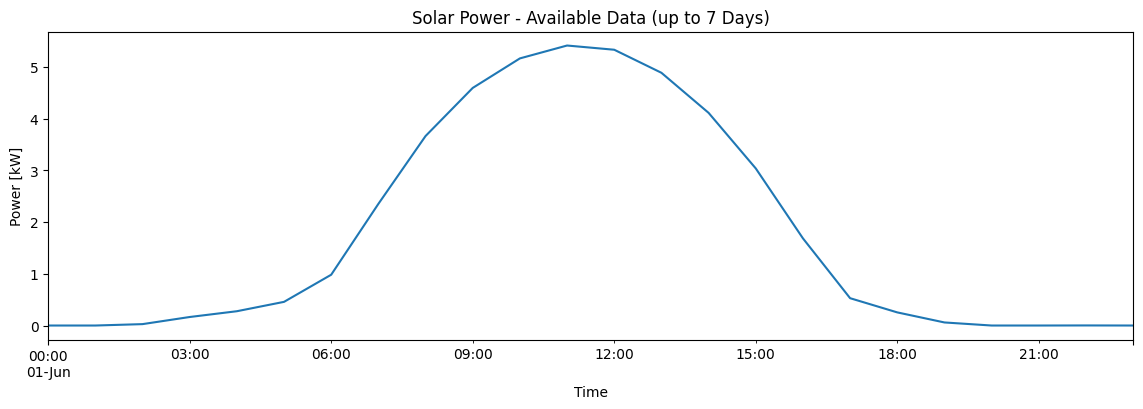

In [8]:
sample = df.loc[df.index < df.index[0] + pd.Timedelta(days=7)]

sample["P_Solar[kW]"].plot(figsize=(14, 4))

plt.title("Solar Power - Available Data (up to 7 Days)")
plt.ylabel("Power [kW]")
plt.xlabel("Time")
plt.show()

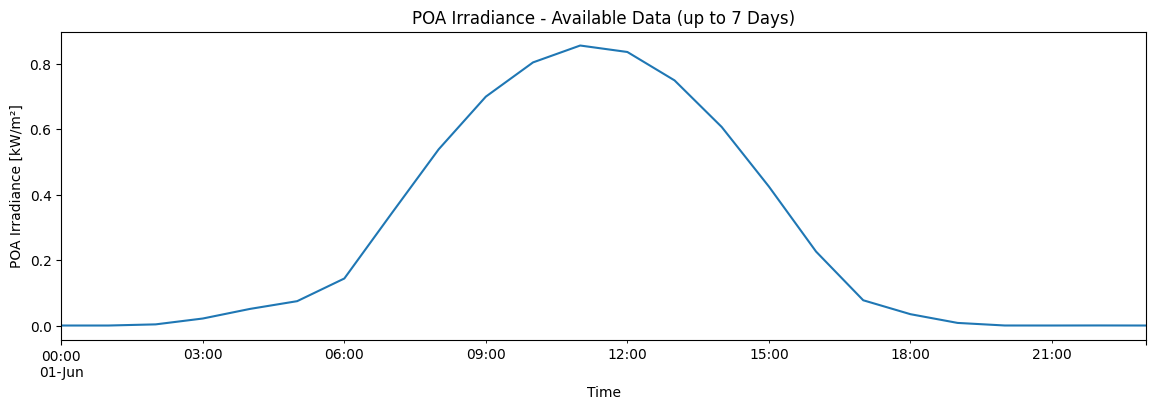

In [9]:
sample["POA Irr[kW1m2]"].plot(figsize=(14, 4))

plt.title("POA Irradiance - Available Data (up to 7 Days)")
plt.ylabel("POA Irradiance [kW/m²]")
plt.xlabel("Time")
plt.show()

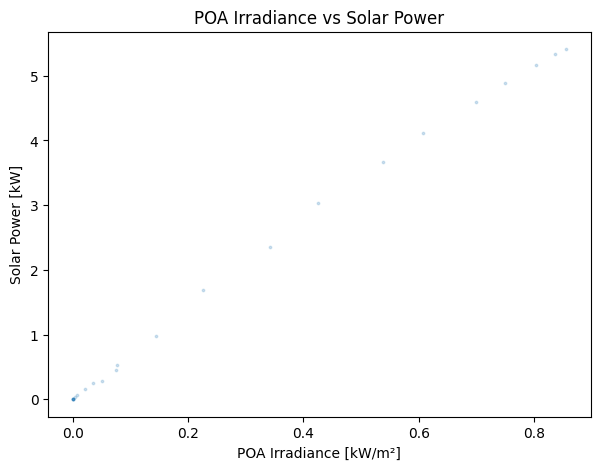

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["POA Irr[kW1m2]"],
    df["P_Solar[kW]"],
    s=3,
    alpha=0.2
)

plt.xlabel("POA Irradiance [kW/m²]")
plt.ylabel("Solar Power [kW]")
plt.title("POA Irradiance vs Solar Power")

plt.show()